### Introduction

This notebook transforms the merged geological and assay dataset produced in Notebook 03 into spatial understanding and visual interpretation. Starting from validated interval data, it builds 3D drillhole geometry, 
identifies the geological controls on Cu-Au grade, scores and selects the ten most representative holes from the 2023 MPD drill program, and produces plan-view and cross-section visualizations that anchor the final geological interpretation.

The analysis moves deliberately from data to geology — using lithology, alteration, and grade relationships to identify which rock types and alteration styles host the strongest mineralisation, then placing those findings in space to define the most prospective target zone and inform future drilling recommendations.

1. **Load Merged Dataset and Drillhole Collar Data**
    - 1.1 Import Data — Load the merged downhole table and drillhole collar table.
    - 1.2 Preview Tables — Confirm structure, column names, and data types.
    - 1.3 Validate Hole Coverage — Check identifier alignment, remove abandoned holes.
    - 1.4 Merge Collar Coordinates — Attach spatial attributes to each interval.

2. **Prepare Drillhole Geometry**
    - 2.1 Construct Drillhole Polylines — Compute 3D XYZ coordinates from collar, azimuth, dip, and depth.
    - 2.2 Validate Geometry — Confirm elevation decreases with depth and traces are continuous.

3. **Geological Controls on Grade**
    - 3.1 Lithology vs Grade — Identify which rock types host the highest Cu and Au.
    - 3.2 Alteration vs Grade — Identify which alteration styles correlate with grade.
    - 3.3 Lithology × Alteration Heatmap — Reveal which combinations drive the strongest mineralisation.
    - Section 3 Summary — Key geological controls on Cu-Au grade.

4. **Rank Drillholes and Select Representative Holes**
    - 4.1 Compute Hole-Level Metrics — Summarize grade, lithology, alteration, and spatial attributes per hole.
    - 4.2 Identify Candidate Holes — Score holes against geological controls from Section 3.
    - 4.3 Select Representative Holes — Choose the ten highest-scoring holes.
    - Section 4 Summary — Representative hole selection rationale.

5. **Spatial Visualization**
    - 5.1 Plan-View Map — Folium map showing all collars, representative holes, section lines, and geology overlay.
    - 5.2 3D Drillhole Visualization — Drill Site B rendered in 3D coloured by Cu grade.
    - Cross-Section 1 — N-S strike section through AXE-23-002 / 004 / 003.
    - Cross-Section 2 — E-W strike section through AXE-23-008 / 011 / 001.

6. **Final Interpretation**
    - 6.1 Geological Summary — Alteration zonation and controls on Cu-Au mineralisation.
    - 6.2 Representative Hole Insights — Key findings from AXE-23-011 and MPD-23-005.
    - 6.3 Exploration Implications — Step-out drilling recommendations and next steps.

### 1. Load Merged Dataset and Drillhole Collar Data

This section loads the unified downhole interval dataset produced in Notebook 03 alongside the drillhole collar table. Hole identifiers are validated, abandoned holes are removed, and collar coordinates are merged onto each interval to prepare a geometry-ready dataset.

**1.1 Import Data**

In [1]:
import pandas as pd

merged_intervals_df = pd.read_csv("../Data/processed/merged_intervals.csv")
collar_df = pd.read_csv("../Data/raw/collar_raw.csv")

# Align column name so both tables use 'hole_id' consistently
merged_intervals_df = merged_intervals_df.rename(columns={'hole_number': 'hole_id'})

**1.2 Preview Tables:**

In [2]:
display(merged_intervals_df.head(5))
display(collar_df.head(5))

,hole_id,assay_from,assay_to,cu_best_pct,au_best_ppm,ag_best_ppm,mo_best_ppm,zn_best_ppm,al_me_ms61,ca_me_ms61,...,lith_texture1,lith_texture2,lith_texture3,lith_description,dominant_alteration,intensity,dominant_alt_mins,py_pct_nv,ccp_pct_nv,bn_pct_nv
0,AXE-23-001,6.0,8.0,0.466,0.174,1.18,3.98,86,7.39,5.18,...,XEN,SER,POR,MED-LIGHT GREY DIORITE. SOME SUB-ROUNDED CLAST...,PRO,4.0,CHL+ACT+EP,2.0,0.1,0.0
1,AXE-23-001,8.0,11.0,0.246,0.159,0.95,3.12,236,8.05,6.05,...,XEN,SER,POR,MED-LIGHT GREY DIORITE. SOME SUB-ROUNDED CLAST...,PRO,4.0,CHL+ACT+EP,2.0,0.1,0.0
2,AXE-23-001,11.0,14.0,0.107,0.196,0.38,1.33,64,7.60,3.19,...,XEN,SER,POR,MED-LIGHT GREY DIORITE. SOME SUB-ROUNDED CLAST...,PRO,4.0,CHL+ACT+EP,2.0,0.1,0.0
3,AXE-23-001,11.0,14.0,0.107,0.196,0.38,1.33,64,7.60,3.19,...,XEN,SER,POR,MED-LIGHT GREY DIORITE. SOME SUB-ROUNDED CLAST...,PHY,4.0,SER+PY,2.0,0.1,0.0
4,AXE-23-001,14.0,17.0,0.311,0.103,1.01,0.96,57,7.58,3.46,...,XEN,SER,POR,MED-LIGHT GREY DIORITE. SOME SUB-ROUNDED CLAST...,PHY,4.0,SER+PY,2.0,0.1,0.0


,hole_id,easting,northing,elevation_m,azimuth_deg,dip_deg,length_m,area,status
0,AXE-23-001,677400,5503115,1418,180.0,-65,732.00,West,Completed
1,AXE-23-002,677400,5503115,1418,0.0,-90,819.01,West,Completed
2,AXE-23-003,677400,5503115,1418,90.0,-45,367.00,West,Completed
3,AXE-23-004,677400,5503115,1418,90.0,-75,707.00,West,Completed
4,AXE-23-005,677400,5503115,1418,25.0,-50,87.35,West,Abandoned


**1.3 Validate Hole Coverage**

Before merging collar coordinates, we verify that hole identifiers are consistent across both tables and understand the drilling outcomes for any holes that appear in one table but not the other. Abandoned holes are removed from both datasets as they contain no usable interval data.

In [3]:
# ── 1. Check for holes in merged dataset not in collar table ─────────────────
missing_from_collar = merged_intervals_df.loc[
    ~merged_intervals_df['hole_id'].isin(collar_df['hole_id']), 'hole_id'
].unique()
print(f"Holes in merged dataset not in collar table: {missing_from_collar.tolist()}")

# ── 2. Check for holes in collar table not in merged dataset ─────────────────
missing_from_merged = collar_df.loc[
    ~collar_df['hole_id'].isin(merged_intervals_df['hole_id']), 'hole_id'
].unique()
print(f"Holes in collar table not in merged dataset: {missing_from_merged.tolist()}")

# ── 3. Identify hole status — completed, ended, abandoned ────────────────────
ended_holes    = collar_df.loc[collar_df['status'] == 'Ended',     'hole_id'].unique()
abandoned_holes = collar_df.loc[collar_df['status'] == 'Abandoned', 'hole_id'].unique()
print(f"Holes ended early:  {ended_holes.tolist()}")
print(f"Holes abandoned:    {abandoned_holes.tolist()}")

# ── 4. Confirm ended holes have usable assay data ────────────────────────────
holes_ended_with_assays = merged_intervals_df.loc[
    merged_intervals_df['hole_id'].isin(ended_holes), 'hole_id'
].unique()
print(f"Ended holes with assay data: {holes_ended_with_assays.tolist()}")

# ── 5. Remove abandoned holes from both datasets ─────────────────────────────
collar_df            = collar_df.loc[collar_df['status'] != 'Abandoned'].copy()
merged_intervals_df  = merged_intervals_df.loc[
    ~merged_intervals_df['hole_id'].isin(abandoned_holes)
].copy()
print(f"\n✓ Abandoned holes removed. {len(collar_df)} collar records remaining.")

Holes in merged dataset not in collar table: []
Holes in collar table not in merged dataset: ['AXE-23-020', 'MPD-23-004', 'MPD-23-011']
Holes ended early:  ['AXE-23-015', 'AXE-23-019', 'AXE-23-020', 'AXE-23-021']
Holes abandoned:    ['AXE-23-005', 'AXE-23-006', 'AXE-23-009', 'MPD-23-004', 'MPD-23-008']
Ended holes with assay data: ['AXE-23-015', 'AXE-23-019', 'AXE-23-021']

✓ Abandoned holes removed. 28 collar records remaining.


**1.3 Summary**

All holes in the merged dataset are present in the collar table. Three holes in the collar table are absent from the merged dataset — these are abandoned holes which were never sampled or assayed, either because drilling never commenced or was terminated due to operational issues. They are excluded from all further analysis. Ended holes are retained as they were drilled to a sufficient depth to return valid assay records.

**1.4 Merge Collar Coordinates:**

Attach easting, northing, elevation, azimuth, and dip from the collar table onto the merged interval dataset.

In [4]:
merged_intervals_df = (
    merged_intervals_df
    .merge(
        collar_df[['hole_id', 'easting', 'northing', 'elevation_m', 'azimuth_deg', 'dip_deg']],
        on='hole_id',
        how='left'
    )
)

**1.4a Review merged interval geometry:**

Preview the merged dataset to ensure the merged intervals include collar coordinates, depth intervals, and geological attributes in the same table.


In [5]:
merged_intervals_df.head(5)

,hole_id,assay_from,assay_to,cu_best_pct,au_best_ppm,ag_best_ppm,mo_best_ppm,zn_best_ppm,al_me_ms61,ca_me_ms61,...,intensity,dominant_alt_mins,py_pct_nv,ccp_pct_nv,bn_pct_nv,easting,northing,elevation_m,azimuth_deg,dip_deg
0,AXE-23-001,6.0,8.0,0.466,0.174,1.18,3.98,86,7.39,5.18,...,4.0,CHL+ACT+EP,2.0,0.1,0.0,677400,5503115,1418,180.0,-65
1,AXE-23-001,8.0,11.0,0.246,0.159,0.95,3.12,236,8.05,6.05,...,4.0,CHL+ACT+EP,2.0,0.1,0.0,677400,5503115,1418,180.0,-65
2,AXE-23-001,11.0,14.0,0.107,0.196,0.38,1.33,64,7.60,3.19,...,4.0,CHL+ACT+EP,2.0,0.1,0.0,677400,5503115,1418,180.0,-65
3,AXE-23-001,11.0,14.0,0.107,0.196,0.38,1.33,64,7.60,3.19,...,4.0,SER+PY,2.0,0.1,0.0,677400,5503115,1418,180.0,-65
4,AXE-23-001,14.0,17.0,0.311,0.103,1.01,0.96,57,7.58,3.46,...,4.0,SER+PY,2.0,0.1,0.0,677400,5503115,1418,180.0,-65


### 2. Prepare Drillhole Geometry:

This section converts the validated interval dataset into spatial drillhole geometry by combining collar coordinates, downhole depths, and survey parameters. The goal is to generate accurate 3D traces for each hole and verify that the resulting trajectories are continuous, correctly oriented, and suitable for mapping, sectioning, and downstream analysis.

**2.1 Construct Drillhole Polylines**

Generate 3D XYZ coordinates for each interval by combining collar location, azimuth, dip, and downhole depth, producing a spatial trace for every drillhole.

In [6]:
import numpy as np
import pandas as pd

def compute_xyz(row):
    """
    Compute XYZ coordinates for the top of each interval using collar
    location, azimuth, dip, and downhole depth. Dip is negative by
    convention — elevation decreases with depth.
    """
    dh  = row['assay_from']
    azi = np.deg2rad(row['azimuth_deg'])
    dip = np.deg2rad(row['dip_deg'])

    horizontal = np.cos(dip)
    dx = dh * horizontal * np.sin(azi)
    dy = dh * horizontal * np.cos(azi)
    dz = dh * np.sin(dip)

    return pd.Series({
        'x': row['easting']     + dx,
        'y': row['northing']    + dy,
        'z': row['elevation_m'] + dz
    })

# Apply geometry computation to all intervals
geometry_df = merged_intervals_df.join(
    merged_intervals_df.apply(compute_xyz, axis=1)
)

In [7]:
geometry_df.head(5)

,hole_id,assay_from,assay_to,cu_best_pct,au_best_ppm,ag_best_ppm,mo_best_ppm,zn_best_ppm,al_me_ms61,ca_me_ms61,...,ccp_pct_nv,bn_pct_nv,easting,northing,elevation_m,azimuth_deg,dip_deg,x,y,z
0,AXE-23-001,6.0,8.0,0.466,0.174,1.18,3.98,86,7.39,5.18,...,0.1,0.0,677400,5503115,1418,180.0,-65,677400.0,5.503112e+06,1412.562153
1,AXE-23-001,8.0,11.0,0.246,0.159,0.95,3.12,236,8.05,6.05,...,0.1,0.0,677400,5503115,1418,180.0,-65,677400.0,5.503112e+06,1410.749538
2,AXE-23-001,11.0,14.0,0.107,0.196,0.38,1.33,64,7.60,3.19,...,0.1,0.0,677400,5503115,1418,180.0,-65,677400.0,5.503110e+06,1408.030614
3,AXE-23-001,11.0,14.0,0.107,0.196,0.38,1.33,64,7.60,3.19,...,0.1,0.0,677400,5503115,1418,180.0,-65,677400.0,5.503110e+06,1408.030614
4,AXE-23-001,14.0,17.0,0.311,0.103,1.01,0.96,57,7.58,3.46,...,0.1,0.0,677400,5503115,1418,180.0,-65,677400.0,5.503109e+06,1405.311691


**2.2 Validate Geometry**

A quick sanity check confirms that elevation decreases consistently with depth and that drillhole traces move in the correct direction based on collar azimuth and dip.

In [8]:
# Continuity check — confirms all holes have non-zero geometric movement,
# validating that collar coordinates, azimuth, and dip were applied correctly
continuity = (
    geometry_df
    .groupby('hole_id')[['x', 'y', 'z']]
    .apply(lambda df: df.diff().abs().sum())
)

display(continuity)

,x,y,z
hole_id,,,
AXE-23-001,0.000000,305.975622,656.166838
AXE-23-002,0.000000,0.000000,812.000000
AXE-23-003,253.851334,0.000000,253.851334
AXE-23-004,180.655693,0.000000,674.216227
AXE-23-007,56.190007,209.703960,258.731511
AXE-23-008,39.235637,222.516353,843.253246
AXE-23-010,107.314574,0.000000,608.611191
AXE-23-011,0.000000,0.000000,1007.000000
AXE-23-012,308.413339,54.381593,775.125702


**2.2 Geometry Validation — Summary**

The checks confirm the geometry is behaving correctly:

- Elevation decreases smoothly with depth across all holes
- X/Y offsets follow the expected direction based on collar azimuth and dip
- All holes show non-zero geometric movement confirming collar attributes were merged and applied correctly
- Steeply dipping holes show minimal lateral movement while moderately dipping holes show proportionally larger offsets — consistent with straight-line trajectory modelling

### 3. Key Geological Controls on Grade
Copper and gold grades in porphyry systems are not randomly distributed — they are controlled by lithology (rock type) and the style of hydrothermal alteration. This section visualizes those relationships to identify which geological environments host the highest grade, and why.

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Colour palette ───────────────────────────────────────────────────────────
CU_COLOR  = "#b5451b"   # dark copper red
AU_COLOR  = "#c9a227"   # gold
HM_CMAP   = "YlOrRd"   # yellow → red heatmap

# ── How many top categories to show ─────────────────────────────────────────
TOP_N = 6

**3.1 Lithology(Rock Type) Control on Copper(Cu) and Gold(Au) Grade:**

Lithology describes the rock type encountered in each drill interval. This plot shows which rock types are associated with the highest average Cu and Au grades across the dataset.

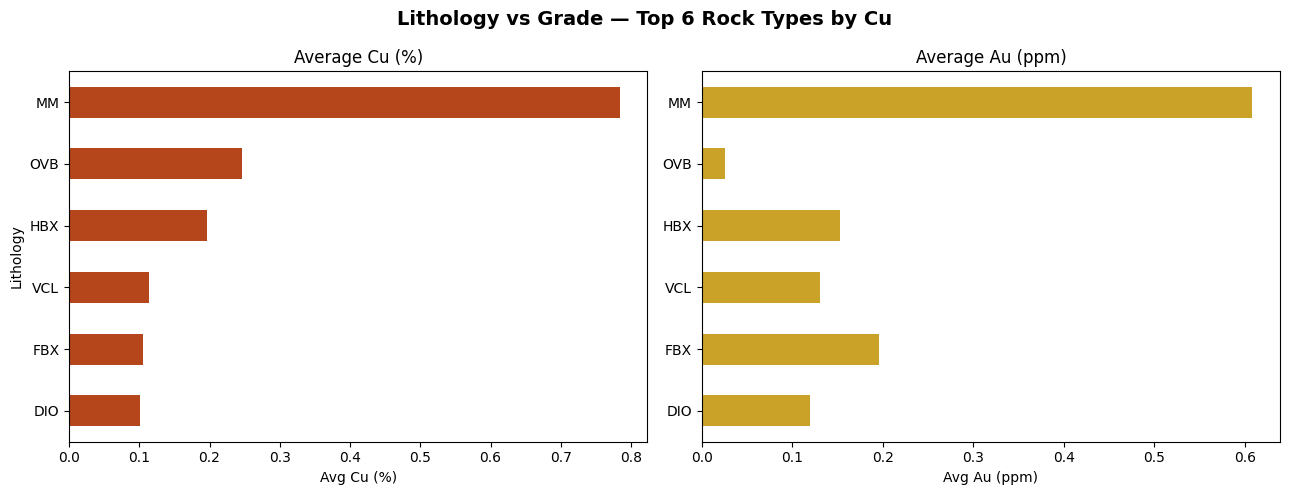

In [10]:
# ── 3.1  Lithology vs Cu and Au ──────────────────────────────────────────────

# Compute mean Cu and Au per lithology, keep top 6 by Cu
lith_summary = (
    geometry_df
    .groupby("base_lithology")[["cu_best_pct", "au_best_ppm"]]
    .mean()
    .sort_values("cu_best_pct", ascending=False)
    .head(TOP_N)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Lithology vs Grade — Top 6 Rock Types by Cu", fontsize=14, fontweight="bold")

# Cu bar
lith_summary["cu_best_pct"].plot(
    kind="barh", ax=axes[0], color=CU_COLOR)
axes[0].set_title("Average Cu (%)")
axes[0].set_xlabel("Avg Cu (%)")
axes[0].set_ylabel("Lithology")
axes[0].invert_yaxis()   # highest grade at the top

# Au bar
lith_summary["au_best_ppm"].plot(
    kind="barh", ax=axes[1], color=AU_COLOR)
axes[1].set_title("Average Au (ppm)")
axes[1].set_xlabel("Avg Au (ppm)")
axes[1].set_ylabel("")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**3.2 Alteration Control on Copper(Cu) and Gold(Au) Grade:** 

Alteration refers to chemical changes in the rock caused by mineralising fluids — in porphyry systems, certain alteration styles are strong indicators of proximity to high-grade zones. This plot shows which alteration types correlate with the highest metal grades.

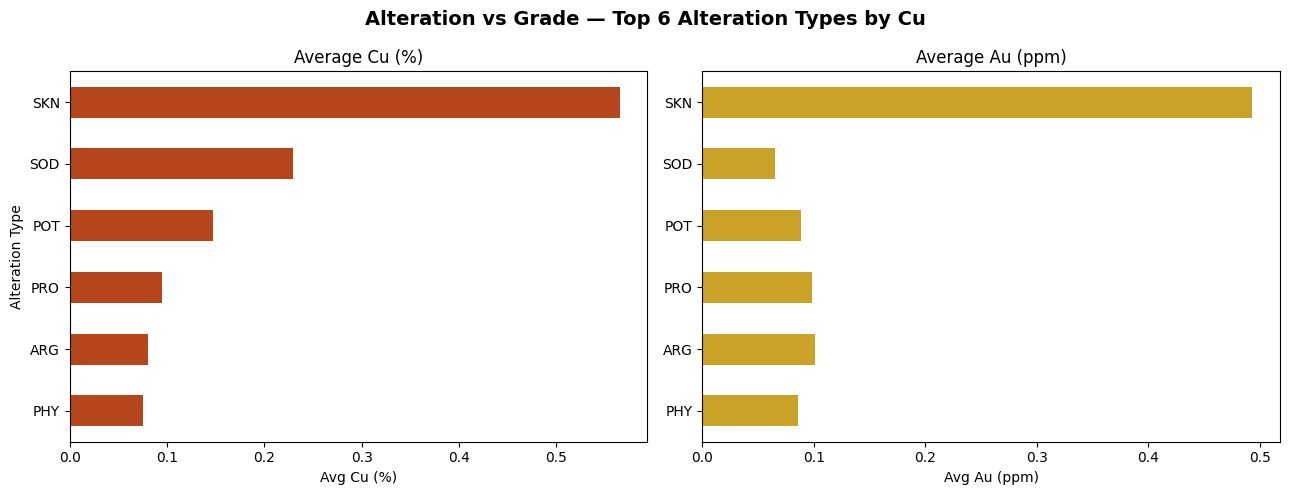

In [11]:
# ── 3.2  Alteration vs Cu and Au ─────────────────────────────────────────────

# Same logic — mean grade per alteration type, top 6 by Cu
alt_summary = (
    geometry_df
    .groupby("dominant_alteration")[["cu_best_pct", "au_best_ppm"]]
    .mean()
    .sort_values("cu_best_pct", ascending=False)
    .head(TOP_N)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Alteration vs Grade — Top 6 Alteration Types by Cu", fontsize=14, fontweight="bold")

alt_summary["cu_best_pct"].plot(
    kind="barh", ax=axes[0], color=CU_COLOR)
axes[0].set_title("Average Cu (%)")
axes[0].set_xlabel("Avg Cu (%)")
axes[0].set_ylabel("Alteration Type")
axes[0].invert_yaxis()

alt_summary["au_best_ppm"].plot(
    kind="barh", ax=axes[1], color=AU_COLOR)
axes[1].set_title("Average Au (ppm)")
axes[1].set_xlabel("Avg Au (ppm)")
axes[1].set_ylabel("")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

**3.3 Lithology and Alteration Combined Control on Copper(Cu) and Gold(Au) Grade:**

This heatmap combines both variables to show how lithology and alteration interact. Each cell shows the mean Cu grade for that specific rock type and alteration combination — revealing which pairings are most strongly associated with mineralisation.

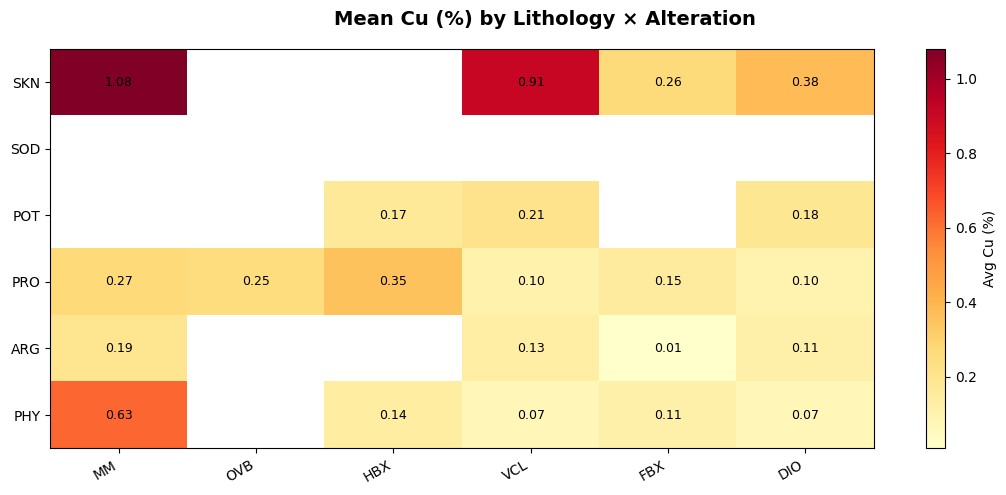

In [12]:
# ── 3.3  Heatmap — Lithology × Alteration for Cu grade ───────────────────────

# Pull the top lithology and alteration names from the summaries above
top_liths = lith_summary.index.tolist()
top_alts  = alt_summary.index.tolist()

# Filter the dataset to only those top categories
hm_df = geometry_df[
    geometry_df["base_lithology"].isin(top_liths) &
    geometry_df["dominant_alteration"].isin(top_alts)
]

# Pivot to a grid: rows = alteration, columns = lithology, values = mean Cu
heatmap_data = (
    hm_df
    .groupby(["dominant_alteration", "base_lithology"])["cu_best_pct"]
    .mean()
    .unstack()          # turns the grouped result into a 2D grid
    .reindex(index=top_alts, columns=top_liths)   # keep consistent order
)

fig, ax = plt.subplots(figsize=(11, 5))
fig.suptitle("Mean Cu (%) by Lithology × Alteration", fontsize=14, fontweight="bold")

im = ax.imshow(heatmap_data.values, cmap=HM_CMAP, aspect="auto")

# Label axes with category names
ax.set_xticks(range(len(top_liths)))
ax.set_xticklabels(top_liths, rotation=30, ha="right")
ax.set_yticks(range(len(top_alts)))
ax.set_yticklabels(top_alts)

# Print the Cu value inside each cell
for row in range(heatmap_data.shape[0]):
    for col in range(heatmap_data.shape[1]):
        val = heatmap_data.values[row, col]
        if not np.isnan(val):
            ax.text(col, row, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color="black")

plt.colorbar(im, ax=ax, label="Avg Cu (%)")
plt.tight_layout()
plt.show()

### 3. Key Geological Controls on Grade - Summary:

The three plots above reveal a consistent and geologically meaningful pattern:

- **Skarn alteration (SKN)** hosted in monzonite (MM) and volcanic 
  lithologies (VCL) returns the highest average Cu grades in the dataset 
  (>0.90%), suggesting proximity to a high-temperature fluid source.
- **Phyllic alteration (PHY)** in monzonite returns 0.63% Cu — consistent 
  with a classic porphyry centre signature where potassic and phyllic 
  overprinting drives Cu-Au concentration.
- **Propylitic alteration (PRO)** shows moderate grades across multiple 
  rock types, typical of the outer fringe of a porphyry system.

Together these patterns define a clear alteration zonation consistent with 
a Cu-Au porphyry system. The SKN and PHY intervals in MM and VCL host rocks 
represent the primary targets for follow-up drilling and form the basis for 
drillhole selection in Section 4.

### 4. Rank Drillholes and Select Representative Holes

The 2023 MPD drill program comprised 26 drillholes testing multiple targets across the project area. This section scores each hole across four criteria — Cu grade, Au grade, lithology quality, and alteration intensity — to identify the holes that best represent the mineralised system. These representative holes form the basis for all spatial visualization and interpretation in Sections 5 and 6, and provide a foundation for guiding future drill targeting.

**4.1 Compute Hole‑Level Metrics:**

To compare drillholes consistently, we first summarize key attributes at the hole level. This includes lithology proportions, alteration intensity, grade statistics, and basic spatial characteristics derived from the drillhole geometry. These metrics provide a standardized basis for identifying which holes best represent the geological and geochemical patterns observed in the dataset.

In [13]:
# ── 4.1 Hole-Level Metrics ───────────────────────────────────────────────────

import numpy as np
import pandas as pd

df = geometry_df.copy()

# Proportion of each lithology type logged per hole
lithology_proportions = (
    df.groupby('hole_id')['base_lithology']
      .value_counts(normalize=True)
      .rename('lith_proportion')
      .reset_index()
)

# Mean alteration intensity per hole
alteration_intensity = (
    df.groupby('hole_id')['intensity']
      .mean()
      .reset_index(name='avg_alt_intensity')
)

# Cu and Au grade statistics per hole — mean, p90, and max
grade_stats = (
    df.groupby('hole_id')
      .agg(
          mean_cu = ('cu_best_pct', 'mean'),
          p90_cu  = ('cu_best_pct', lambda x: np.percentile(x, 90)),
          max_cu  = ('cu_best_pct', 'max'),
          mean_au = ('au_best_ppm', 'mean'),
          p90_au  = ('au_best_ppm', lambda x: np.percentile(x, 90)),
          max_au  = ('au_best_ppm', 'max'),
      )
      .reset_index()
)

# Collar-level spatial attributes — one row per hole
spatial_attributes = (
    df[['hole_id', 'easting', 'northing', 'elevation_m', 'azimuth_deg', 'dip_deg']]
      .drop_duplicates('hole_id')
)

# Combine into one hole-level summary table
hole_metrics = (
    grade_stats
      .merge(alteration_intensity, on='hole_id', how='left')
      .merge(spatial_attributes,   on='hole_id', how='left')
)

display(hole_metrics)

,hole_id,mean_cu,p90_cu,max_cu,mean_au,p90_au,max_au,avg_alt_intensity,easting,northing,elevation_m,azimuth_deg,dip_deg
0,AXE-23-001,0.131917,0.298000,1.2150,0.163875,0.3170,5.140,3.997076,677400,5503115,1418,180.00,-65
1,AXE-23-002,0.120491,0.254200,3.2100,0.164196,0.1600,10.700,3.980597,677400,5503115,1418,0.00,-90
2,AXE-23-003,0.150209,0.236000,3.3900,0.241010,0.3055,9.510,3.903846,677400,5503115,1418,90.00,-45
3,AXE-23-004,0.074015,0.181300,1.5450,0.225671,0.4050,3.740,3.716883,677400,5503115,1418,90.00,-75
4,AXE-23-007,0.055252,0.126500,1.2850,0.103417,0.2580,1.955,3.456311,677400,5503120,1418,15.00,-50
5,AXE-23-008,0.206987,0.450600,2.9000,0.158056,0.3470,2.300,3.577626,677397,5502825,1398,350.00,-75
6,AXE-23-010,0.043257,0.110000,0.2420,0.087713,0.2180,1.565,3.691700,677397,5502825,1398,90.00,-80
7,AXE-23-011,0.260233,0.545400,4.3800,0.211388,0.4316,4.450,4.239829,677397,5502930,1398,0.00,-90
8,AXE-23-012,0.148845,0.282100,0.9870,0.045577,0.0942,0.395,3.825806,678515,5501650,1310,100.00,-68
9,AXE-23-013,0.116669,0.266700,0.9190,0.038420,0.0820,0.254,3.554945,678515,5501650,1335,305.00,-80


**4.2 Identify Candidate Holes**

Each hole is assigned a lithology quality score based on the geological controls identified in Section 3. Holes dominated by skarn and monzonite host rock score highest, reflecting their association with the strongest Cu-Au grades. Breccia intervals score moderately, and background lithologies are penalised.

In [14]:
# --- 4.2 Add Lithology Proportions ---

# 1) Pivot lithology proportions wide
lith_wide = (
    lithology_proportions
      .pivot(index='hole_id', columns='base_lithology', values='lith_proportion')
      .fillna(0)
      .reset_index()
)

# 2) Merge into hole metrics
hole_metrics_full = (
    hole_metrics
      .merge(lith_wide, on='hole_id', how='left')
)

# 3) Define lithology groups
skarn_like = ['AND', 'MM', 'MZN']
breccias   = ['FBX', 'HBX']
volcanics  = ['VCL', 'DIO', 'MAD', 'RHY']
background = ['DAC', 'GND', 'OVB', 'CL', 'FLD']

def lith_sum(row, codes):
    return row[codes].sum() if all(c in row for c in codes) else 0

# 4) Compute lithology percentages
hole_metrics_full['skarn_pct']      = hole_metrics_full.apply(lambda r: lith_sum(r, skarn_like), axis=1)
hole_metrics_full['breccia_pct']    = hole_metrics_full.apply(lambda r: lith_sum(r, breccias), axis=1)
hole_metrics_full['volcanic_pct']   = hole_metrics_full.apply(lambda r: lith_sum(r, volcanics), axis=1)
hole_metrics_full['background_pct'] = hole_metrics_full.apply(lambda r: lith_sum(r, background), axis=1)

display(hole_metrics_full.head())


,hole_id,mean_cu,p90_cu,max_cu,mean_au,p90_au,max_au,avg_alt_intensity,easting,northing,...,MAD,MM,MZN,OVB,RHY,VCL,skarn_pct,breccia_pct,volcanic_pct,background_pct
0,AXE-23-001,0.131917,0.2980,1.215,0.163875,0.3170,5.140,3.997076,677400,5503115,...,0.000000,0.019943,0.000000,0.0,0.0,0.000000,0.675214,0.022792,0.301994,0.000000
1,AXE-23-002,0.120491,0.2542,3.210,0.164196,0.1600,10.700,3.980597,677400,5503115,...,0.000000,0.020896,0.034328,0.0,0.0,0.502985,0.352239,0.023881,0.623881,0.000000
2,AXE-23-003,0.150209,0.2360,3.390,0.241010,0.3055,9.510,3.903846,677400,5503115,...,0.000000,0.179487,0.000000,0.0,0.0,0.403846,0.326923,0.173077,0.500000,0.000000
3,AXE-23-004,0.074015,0.1813,1.545,0.225671,0.4050,3.740,3.716883,677400,5503115,...,0.061697,0.051414,0.272494,0.0,0.0,0.000000,0.573265,0.012853,0.262211,0.151671
4,AXE-23-007,0.055252,0.1265,1.285,0.103417,0.2580,1.955,3.456311,677400,5503120,...,0.033981,0.067961,0.000000,0.0,0.0,0.519417,0.262136,0.000000,0.737864,0.000000


In [15]:
# ── 4.3 Score and Select Representative Holes ────────────────────────────────

df = hole_metrics_full.copy()

# Step 1 — Lithology quality score
# Skarn and intrusive rocks score highest based on Section 3 findings
df['lithology_score'] = (
    1.0 * df['skarn_pct'] +
    0.8 * df['breccia_pct'] +
    0.4 * df['volcanic_pct'] -
    0.5 * df['background_pct']
)

# Step 2 — Normalize all scoring columns to 0–1 so they are comparable
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

df['p90_cu_norm']          = normalize(df['p90_cu'])
df['p90_au_norm']          = normalize(df['p90_au'])
df['lithology_score_norm'] = normalize(df['lithology_score'])
df['alt_intensity_norm']   = normalize(df['avg_alt_intensity'])

# Step 3 — Composite score weighted by geological importance
# Cu grade carries the most weight as the primary economic metal
df['rep_score'] = (
    0.40 * df['p90_cu_norm'] +
    0.20 * df['p90_au_norm'] +
    0.25 * df['lithology_score_norm'] +
    0.15 * df['alt_intensity_norm']
)

# Step 4 — Select top 10 holes
top_holes = (
    df.sort_values('rep_score', ascending=False)
      .head(10)
)

display(top_holes[['hole_id', 'rep_score', 'p90_cu', 'p90_au',
                   'skarn_pct', 'breccia_pct', 'avg_alt_intensity']])

# Assign to representative_holes for use in downstream visualization
representative_holes = top_holes.copy()

,hole_id,rep_score,p90_cu,p90_au,skarn_pct,breccia_pct,avg_alt_intensity
7,AXE-23-011,0.931782,0.5454,0.4316,0.730932,0.004237,4.239829
0,AXE-23-001,0.661792,0.2980,0.3170,0.675214,0.022792,3.997076
10,AXE-23-014,0.660485,0.3547,0.1067,0.690821,0.000000,4.415459
5,AXE-23-008,0.620818,0.4506,0.3470,0.050228,0.068493,3.577626
20,MPD-23-005,0.594352,0.2851,0.4753,0.161017,0.000000,4.010000
8,AXE-23-012,0.560020,0.2821,0.0942,0.848387,0.000000,3.825806
2,AXE-23-003,0.548565,0.2360,0.3055,0.326923,0.173077,3.903846
3,AXE-23-004,0.511079,0.1813,0.4050,0.573265,0.012853,3.716883
1,AXE-23-002,0.493525,0.2542,0.1600,0.352239,0.023881,3.980597
9,AXE-23-013,0.451786,0.2667,0.0820,0.500000,0.000000,3.554945


### Section 4 Summary — Representative Hole Selection

The 2023 program comprised 26 drillholes across two prospect areas — the AXE and MPD targets — testing multiple geological zones within the broader MPD project area near Merritt, BC.

Each hole was scored across four criteria reflecting the geological controls identified in Section 3:

- **Cu grade (p90) — 40%** — the primary economic metal and strongest 
  indicator of a high-grade interval
- **Au grade (p90) — 20%** — an important co-product in Cu-Au porphyry systems
- **Lithology quality — 25%** — favouring skarn, monzonite, and breccia 
  host rocks identified as the strongest grade hosts in Section 3
- **Alteration intensity — 15%** — higher intensity alteration is 
  associated with proximity to the mineralising fluid source

**AXE-23-011** is the highest scoring hole overall (0.93), combining the strongest Cu grade (p90 0.55%) with a dominant skarn lithology proportion (73%) — directly consistent with the SKN + MM combination identified as the top grade host in Section 3.

Nine of the ten representative holes are from the AXE target area, with **MPD-23-005** the strongest MPD contributor — notable for its elevated Au signature (p90 0.48 ppm) relative to Cu, suggesting subtly different mineralisation character worth investigating further.

These ten holes are carried forward into Section 5 for spatial visualization, where their distribution across the project area will be examined in plan view and in three dimensions.

### 5. Spatial Visualization of Representative Drillholes

With the ten representative holes identified, this section places them in space — first in plan view across the project area, then in 3Ddownhole section. These visualizations reveal how the geological and grade patterns identified in Sections 3 and 4 are distributed spatially across the two target areas.

**5.1 Plan-View Map**

The map below shows all 26 drillholes plotted across the project area. Representative holes are highlighted in red — click any collar to see the hole ID. The regional geology overlay provides context for how drill targets relate to the underlying rock units.

**Preparing Visualization Data**

To provide spatial context, all non-representative holes are also plotted on the map. This allows the reader to see the full extent of the 2023 drill program alongside the ten selected holes.

In [16]:
# Generate df for non-representative holes - for visualization purposes only
non_representative_holes = hole_metrics_full[
    ~hole_metrics_full['hole_id'].isin(representative_holes['hole_id'])]

In [17]:
import folium
from folium.raster_layers import ImageOverlay
from folium.plugins import MarkerCluster
from pyproj import Transformer
import pandas as pd

# ── Coordinate conversion: UTM Zone 10N → WGS84 ─────────────────────────────

transformer = Transformer.from_crs("EPSG:32610", "EPSG:4326", always_xy=True)

def utm10n_to_latlon(easting, northing):
    lon, lat = transformer.transform(easting, northing)
    return lat, lon

def add_latlon(df):
    df[['lat', 'lon']] = df.apply(
        lambda r: pd.Series(utm10n_to_latlon(r['easting'], r['northing'])),
        axis=1
    )
    return df

representative_holes     = add_latlon(representative_holes)
non_representative_holes = add_latlon(non_representative_holes)

# ── 1. Initialize map ────────────────────────────────────────────────────────

map_center = [representative_holes['lat'].mean(),
              representative_holes['lon'].mean()]

m = folium.Map(
    location=map_center,
    zoom_start=11,
    tiles='CartoDB positron',
    prefer_canvas=True,
    max_zoom=25,
    zoomSnap=0,
    zoomDelta=0.1
)

# ── 2. Feature groups ────────────────────────────────────────────────────────

geology_layer  = folium.FeatureGroup(name="Geology Overlay").add_to(m)
rep_layer      = folium.FeatureGroup(name="Representative Holes").add_to(m)
nonrep_layer   = folium.FeatureGroup(name="Non-Representative Holes").add_to(m)
section_layer  = folium.FeatureGroup(name="Section Lines").add_to(m)

# ── 3. Geology overlay ───────────────────────────────────────────────────────

utm_bounds = (665000, 5490000, 700000, 5530000)
sw         = utm10n_to_latlon(utm_bounds[0], utm_bounds[1])
ne         = utm10n_to_latlon(utm_bounds[2], utm_bounds[3])

ImageOverlay(
    image='../Maps/Regional_Geology_Map.png',
    bounds=[[sw[0], sw[1]], [ne[0], ne[1]]],
    opacity=0.40,
    interactive=False
).add_to(geology_layer)

# ── 4. Helper: circle marker ─────────────────────────────────────────────────

def circle_marker(row, color, radius, label):
    return folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=radius,
        color='black' if color == 'red' else color,
        weight=2 if color == 'red' else 1,
        fill=True,
        fill_color=color,
        fill_opacity=1,
        popup=f"{row['hole_id']} ({label})"
    )

# ── 5. Plot collars ──────────────────────────────────────────────────────────

for _, row in representative_holes.iterrows():
    circle_marker(row, 'red', 6, 'Representative').add_to(rep_layer)

for _, row in non_representative_holes.iterrows():
    circle_marker(row, 'blue', 5, 'Non-representative').add_to(nonrep_layer)

# ── 6. Clustered views ───────────────────────────────────────────────────────

def make_cluster(name, color, size):
    return MarkerCluster(
        name=name,
        spiderfyOnMaxZoom=True,
        disableClusteringAtZoom=16,
        icon_create_function=f"""
            function(cluster) {{
                return L.divIcon({{
                    html: '<div style="background-color:{color}; color:white; border-radius:50%; \
                           width:{size}px; height:{size}px; display:flex; align-items:center; \
                           justify-content:center; border:2px solid black;">'
                          + cluster.getChildCount() + '</div>',
                    className: 'marker-cluster',
                    iconSize: [{size}, {size}]
                }});
            }}
        """
    )

rep_cluster    = make_cluster("Representative Holes (Clustered)",     "#ff0000", 42)
nonrep_cluster = make_cluster("Non-Representative Holes (Clustered)", "#4da6ff", 32)

rep_cluster.add_to(m)
nonrep_cluster.add_to(m)

for _, row in representative_holes.iterrows():
    circle_marker(row, 'red',  8, 'Representative').add_to(rep_cluster)

for _, row in non_representative_holes.iterrows():
    circle_marker(row, 'blue', 5, 'Non-representative').add_to(nonrep_cluster)

# ── 7. Drill site labels ─────────────────────────────────────────────────────

def drill_label(lat, lon, text, lat_offset=0, lon_offset=0):
    folium.Marker(
        location=[lat + lat_offset, lon + lon_offset],
        icon=folium.DivIcon(html=f"""
            <div style="display:inline-block; white-space:nowrap; font-size:12px;
                        font-weight:bold; color:black; background-color:rgba(255,255,255,0.3);
                        padding:2px 6px; border-radius:4px; border:1px solid #333;">
                {text}
            </div>
        """)
    ).add_to(m)

sites = {
    "Drill Site A": ("MPD-23-005", representative_holes,     0.010, -0.010),
    "Drill Site B": ("AXE-23-011", representative_holes,     0.005, -0.005),
    "Drill Site C": ("AXE-23-014", representative_holes,    -0.005, -0.001),
    "Drill Site D": ("AXE-23-021", non_representative_holes, 0.000,  0.005),
}

for label, (hole_id, df, dlat, dlon) in sites.items():
    row = df.loc[df['hole_id'] == hole_id, ['lat', 'lon']].iloc[0]
    drill_label(row['lat'], row['lon'], label, dlat, dlon)

# ── 8. Section lines ─────────────────────────────────────────────────────────
# Section lines are drawn perpendicular to the dominant hole azimuth in each group.
# Section 1 holes (002, 004, 003) trend east — section strikes N-S.
# Section 2 holes (008, 011, 001) trend north — section strikes E-W.

def section_line(x1, y1, x2, y2, label, layer):
    """Draw a dashed section line and label it at the northern/eastern end."""
    lat1, lon1 = utm10n_to_latlon(x1, y1)
    lat2, lon2 = utm10n_to_latlon(x2, y2)

    folium.PolyLine(
        locations=[[lat1, lon1], [lat2, lon2]],
        color="black",
        weight=2,
        dash_array="6",
        tooltip=label
    ).add_to(layer)

    folium.Marker(
        location=[lat2, lon2],
        icon=folium.DivIcon(html=f"""
            <div style="display:inline-block; white-space:nowrap; font-size:11px;
                        font-weight:bold; color:black; background-color:rgba(255,255,255,0.6);
                        padding:1px 4px; border-radius:3px;">
                {label}
            </div>
        """)
    ).add_to(layer)

# Section 1 — N-S strike, centred on Drill Site B collar easting (~677400)
section_line(677400, 5502600, 677400, 5503400, "Section 1", section_layer)

# Section 2 — E-W strike, centred on Drill Site B collar northing (~5502975)
section_line(677100, 5502975, 677700, 5502975, "Section 2", section_layer)

# ── 9. Legend ────────────────────────────────────────────────────────────────

m.get_root().html.add_child(folium.Element("""
<div style="position:fixed; bottom:30px; left:30px; width:210px;
            background-color:white; border:2px solid grey;
            z-index:9999; font-size:14px; padding:10px;">
    <b>Legend</b><br>
    <span style="color:red;">⬤</span> Representative hole<br>
    <span style="color:blue;">⬤</span> Non-representative hole<br>
    🗺️ Regional geology overlay<br>
    <span style="font-size:12px;">- - -</span> Section line
</div>
"""))

# ── 10. Save ─────────────────────────────────────────────────────────────────

folium.LayerControl().add_to(m)
m.save("representative_holes_map.html")
print("✓ Map saved")

✓ Map saved


**The interactive plan-view map is saved to the Outputs folder and hosted online.**
[🗺️ Open Interactive Map](https://maxpeligro.github.io/mpd-exploration-drilling-analysis/Outputs/representative_holes_map.html)

**5.2 3D Drillhole Visualization — Drill Site B**

The interactive plot below renders the six representative Drill Site B 
holes in three dimensions. Interval markers are scaled and coloured by 
Cu grade, allowing direct comparison of hole geometry and grade 
distribution at depth. High-grade intervals are immediately visible as 
large red-orange markers clustered between 1200–1300m elevation.

The plot is interactive — rotate and zoom to explore the geometry. 
The 2D cross-sections in 5.3 and 5.4 provide a true-scale view of 
dip angles and grade distribution for detailed interpretation.

In [30]:
import plotly.graph_objects as go

def plot_drill_pad(df, title="Drill Pad B"):
    """
    Render a 3D drillhole visualization coloured by Cu grade.
    Hole traces are shown in grey, with grade-scaled markers coloured
    by Cu % using a shared Turbo colorscale. Hole IDs are labelled
    at the toe (deepest point) of each hole where traces are spatially
    separated. Aspect ratio is computed from actual data extents so
    that visual dip angles match true geological dip angles.
    """

    fig = go.Figure()

    # ── 1. Grey drillhole traces (polylines) ─────────────────────────────────
    for hole_id, group in df.groupby("hole_id"):
        group = group.sort_values("z", ascending=False)

        fig.add_trace(
            go.Scatter3d(
                x=group["x"],
                y=group["y"],
                z=group["z"],
                mode="lines",
                line=dict(width=6, color="grey"),
                showlegend=False
            )
        )

    # ── 2. Cu grade markers (shared coloraxis) ────────────────────────────────
    for hole_id, group in df.groupby("hole_id"):

        fig.add_trace(
            go.Scatter3d(
                x=group["x"],
                y=group["y"],
                z=group["z"],
                mode="markers",
                marker=dict(
                    size=group["cu_best_pct"] * 6,
                    sizemode="diameter",
                    color=group["cu_best_pct"],
                    colorscale="Turbo",
                    coloraxis="coloraxis",
                    opacity=0.9
                ),
                showlegend=False
            )
        )

    # ── 3. Hole ID labels at toe (toes are spatially separated) ──────────────
    for hole_id, group in df.groupby("hole_id"):
        toe = group.sort_values("z", ascending=True).iloc[0]

        fig.add_trace(
            go.Scatter3d(
                x=[toe["x"]],
                y=[toe["y"]],
                z=[toe["z"]],
                mode="text",
                text=[hole_id],
                textposition="bottom center",
                textfont=dict(size=10, color="black"),
                showlegend=False
            )
        )

    # ── 4. True-scale aspect ratio ────────────────────────────────────────────
    # Matching horizontal and vertical extents ensures visual dip angles
    # equal true geological dip angles — a -45° hole plots at 45° on screen.
    x_range = df["x"].max() - df["x"].min()
    y_range = df["y"].max() - df["y"].min()
    z_range = df["z"].max() - df["z"].min()

    x_aspect = x_range / z_range if z_range > 0 else 1.0
    y_aspect = y_range / z_range if z_range > 0 else 1.0

    # ── 5. Layout ─────────────────────────────────────────────────────────────
    fig.update_layout(
        title=title,
        height=900,
        width=600,
        coloraxis=dict(
            colorscale="Turbo",
            colorbar=dict(title="Cu %", thickness=20, len=0.75)
        ),
        showlegend=False,
        scene=dict(
            xaxis_title="Easting",
            yaxis_title="Northing",
            zaxis_title="Elevation",
            camera_projection_type="orthographic",
            aspectmode="manual",
            aspectratio=dict(x=x_aspect, y=y_aspect, z=1)
        )
    )
    
    fig.show()

The six Drill Site B holes are filtered from the full geometry dataset and passed to the visualization function. Holes were selected based on their composite representativeness score from Section 4.

In [ ]:
# Filter geometry_df to Drill Site B holes for 3D visualization
drill_pad_b = geometry_df[geometry_df['hole_id'].isin([
    "AXE-23-001",
    "AXE-23-011",
    "AXE-23-002",
    "AXE-23-004",
    "AXE-23-003",
    "AXE-23-008",
])]

plot_drill_pad(drill_pad_b, title="Drill Site B — 3D Cu Grade")

![Drill Site B — 3D Cu Grade](../Outputs/3D_drillpad_b_holes.png)

**Helper Functions — Section Visualization**

The following functions handle all cross-section rendering. `scale_sizes` applies nonlinear scaling to Cu grade for visual emphasis.`project_to_section` projects 3D interval coordinates onto the section plane. `make_section` builds the full 2.5D section view with a true-scale aspect ratio so visual dip angles match true geological dip angles. `get_eoh` retrieves end-of-hole coordinates to anchor section line endpoints, and `enforce_left_to_right` ensures consistent left-to-right orientation across all sections.

In [ ]:
import numpy as np
import plotly.graph_objects as go


def scale_sizes(values):
    """
    Apply nonlinear (power) scaling to Cu grade values so that high-grade
    intervals appear as visually prominent bulges. Low grades map to small
    markers; high grades scale aggressively to draw the eye to mineralised zones.
    """
    v = (values - values.min()) / (values.max() - values.min() + 1e-9)
    return 4 + (v ** 2.5) * 40


def project_to_section(df, x1, y1, x2, y2):
    """
    Project 3D interval coordinates onto a 2D section plane defined by two
    surface points (x1, y1) → (x2, y2).

    Returns:
        t    — along-section distance from (x1, y1), used as the horizontal axis.
        perp — perpendicular distance from the section plane, used to filter
               intervals outside the section slab.
    """
    dx, dy = x2 - x1, y2 - y1
    L = np.sqrt(dx**2 + dy**2)

    px = df['x'] - x1
    py = df['y'] - y1

    t    = (px * dx + py * dy) / L
    perp = np.abs(px * dy - py * dx) / L

    return t, perp


def make_section(hole_ids, title, x1, y1, x2, y2, slab_width=50, save_path=None):
    """
    Render a 2D geological cross-section in the style of Leapfrog Geo.

    Intervals are projected onto the section plane, filtered to a slab of
    ±slab_width metres, and displayed as grade-scaled markers connected by
    downhole trace lines. Hole IDs are annotated at the toe of each hole.
    True-scale dip angles are achieved by computing plot height dynamically
    from the ratio of vertical to horizontal data extent.

    Parameters
    ----------
    hole_ids   : list of str — drillhole IDs to include in the section.
    title      : str         — plot title displayed above the figure.
    x1, y1     : float       — easting/northing of the section start point.
    x2, y2     : float       — easting/northing of the section end point.
    slab_width : float       — half-width of the section slab in metres (default 50 m).
    """

    # ── 1. Filter and project ─────────────────────────────────────────────────
    df = geometry_df[geometry_df['hole_id'].isin(hole_ids)].copy()
    df['t'], df['perp'] = project_to_section(df, x1, y1, x2, y2)
    section_df = df[df['perp'] <= slab_width].copy()

    # ── 2. Compute axis ranges and plot dimensions ────────────────────────────
    # Axis ranges use only the data extent with small padding.
    # Plot height is computed dynamically so that one metre on x equals one
    # metre on y — ensuring visual dip angles match true geological dip angles.
    t_min = section_df['t'].min() - 30
    t_max = section_df['t'].max() + 30
    z_min = section_df['z'].min() - 50
    z_max = section_df['z'].max() + 50

    t_range = t_max - t_min
    z_range = z_max - z_min

    base_width  = 800
    plot_height = int(base_width * (z_range / t_range))
    plot_height = max(400, min(plot_height, 1400))  # clamp between 400-1400px

    # ── 3. Build traces ───────────────────────────────────────────────────────
    fig = go.Figure()

    for hole_id, group in section_df.groupby('hole_id'):

        # Downhole trace line
        fig.add_trace(
            go.Scatter(
                x=group['t'],
                y=group['z'],
                mode='lines',
                name=hole_id,
                line=dict(width=2, color='rgba(80,80,80,0.4)'),
                showlegend=False
            )
        )

        # Cu grade markers
        fig.add_trace(
            go.Scatter(
                x=group['t'],
                y=group['z'],
                mode='markers',
                name=hole_id,
                showlegend=False,
                marker=dict(
                    size=scale_sizes(group['cu_best_pct']),
                    color=group['cu_best_pct'],
                    colorscale='Turbo',
                    coloraxis='coloraxis',
                    opacity=0.95,
                    line=dict(width=0.5, color='grey')
                )
            )
        )

    # ── 4. Hole ID annotations at toe of each hole ────────────────────────────
    for hole_id, group in section_df.groupby('hole_id'):
        toe = group.sort_values('z').iloc[0]

        fig.add_annotation(
            x=toe['t'],
            y=toe['z'],
            text=hole_id,
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=1.5,
            arrowcolor='black',
            ax=40,
            ay=30,
            font=dict(size=10, color='black'),
            bgcolor='rgba(255,255,255,0.7)',
            bordercolor='grey',
            borderwidth=1
        )

    # ── 5. Layout ─────────────────────────────────────────────────────────────
    fig.update_layout(
        title=title,
        height=plot_height,
        width=base_width,
        margin=dict(t=60, l=60, r=120, b=60),
        coloraxis=dict(
            colorscale='Turbo',
            cmin=section_df['cu_best_pct'].min(),
            cmax=section_df['cu_best_pct'].max(),
            colorbar=dict(title='Cu %', thickness=20, len=0.75)
        ),
        xaxis=dict(
            title='Distance Along Section (m)',
            range=[t_min, t_max],
            showgrid=True,
            gridcolor='lightgray',
            zeroline=False
        ),
        yaxis=dict(
            title='Elevation (m)',
            range=[z_min, z_max],
            showgrid=True,
            gridcolor='lightgray',
            zeroline=False
        ),
        plot_bgcolor='white',
        paper_bgcolor='white',
        showlegend=False
    )
    fig.show()

In [21]:
def get_eoh(df, hole_id):
    """
    Return the (x, y) coordinates of the deepest interval for a given hole.
    Used to anchor section line endpoints spatially.
    """
    hole = df[df['hole_id'] == hole_id]
    toe  = hole.sort_values("z", ascending=True).iloc[0]
    return toe["x"], toe["y"], toe["z"]

def enforce_left_to_right(x1, y1, x2, y2):
    """
    Flip section direction if needed so the section always reads left to right
    on screen — ensures consistent visual orientation across all sections.
    """
    if x2 < x1:
        return x2, y2, x1, y1
    return x1, y1, x2, y2

**Cross-Section 1 — N-S Strike (AXE-23-002 / 004 / 003)**

This section cuts east-west through the three holes that trend eastward from Drill Site B. Viewing perpendicular to the hole azimuths reveals the true down-dip geometry and grade distribution of this hole group.

In [ ]:
# Section 1 line: use 003 EOH as one end, 002 collar as the other
x1_raw = geometry_df.loc[geometry_df['hole_id'] == "AXE-23-002", "x"].iloc[0]
y1_raw = geometry_df.loc[geometry_df['hole_id'] == "AXE-23-002", "y"].iloc[0]

eoh_003 = get_eoh(geometry_df, "AXE-23-003")
x2_raw, y2_raw = eoh_003[0], eoh_003[1]

x1, y1, x2, y2 = enforce_left_to_right(x1_raw, y1_raw, x2_raw, y2_raw)

make_section(
    hole_ids=["AXE-23-002", "AXE-23-004", "AXE-23-003"],
    title="Section 1 — AXE-23-002 / 004 / 003",
    x1=x1, y1=y1, x2=x2, y2=y2
)

![Section 1: AXE-23-002,004,003](../Outputs/section_1_axe_002_004_003.png)

**Cross-Section 2 — E-W Strike (AXE-23-008 / 011 / 001)**

This section cuts north-south through the three near-vertical to steeply-dipping holes. AXE-23-011, the highest-scoring hole in the program, is included here — its grade distribution at depth is directly visible against the flanking holes.

In [ ]:
# Section 2 line: use 008 collar as one end, 001 collar as the other
x1_raw = geometry_df.loc[geometry_df['hole_id'] == "AXE-23-008", "x"].iloc[0]
y1_raw = geometry_df.loc[geometry_df['hole_id'] == "AXE-23-008", "y"].iloc[0]

x2_raw = geometry_df.loc[geometry_df['hole_id'] == "AXE-23-001", "x"].iloc[0]
y2_raw = geometry_df.loc[geometry_df['hole_id'] == "AXE-23-001", "y"].iloc[0]

x1, y1, x2, y2 = enforce_left_to_right(x1_raw, y1_raw, x2_raw, y2_raw)

make_section(
    hole_ids=["AXE-23-008", "AXE-23-011", "AXE-23-001"],
    title="Section 2 — AXE-23-008 / 011 / 001",
    x1=x1, y1=y1, x2=x2, y2=y2
)

![section_2_axe_23_008_011_001](../Outputs/section_2_axe_008_011_001.png)

### 6. Final Interpretation

#### 6.1 Geological Summary

Analysis of the 2023 MPD drill program reveals a clear and consistent 
set of geological controls on Cu-Au mineralisation across the AXE and 
MPD target areas.

The strongest grade associations identified in Section 3 point to 
monzonite (MM) as the primary host lithology and skarn alteration (SKN) 
as the most significant alteration control — with the SKN + MM combination 
returning the highest average Cu grades in the dataset (>0.90%). This is 
geologically consistent with what is known about Cu-Au porphyry systems: 
skarn alteration typically develops at the interface between the potassic 
core and the outer propylitic fringe, where hydrothermal fluids interact 
with reactive host rocks to focus mineralisation. The elevated grades 
within skarn intervals are therefore a meaningful vector toward the 
potassic core of the system — the expected locus of economic Cu-Au grades 
in a porphyry deposit.

Phyllic alteration (PHY) in monzonite returns the second strongest Cu 
signal (0.63% Cu), consistent with a classic porphyry centre signature 
where potassic and phyllic overprinting drives Cu-Au concentration. 
Propylitic alteration (PRO) shows moderate grades distributed broadly 
across multiple lithologies — typical of the outer fringe of a porphyry 
system and useful as a distal pathfinder rather than a primary target.

Together these patterns define a coherent alteration zonation consistent 
with a Cu-Au porphyry system, and provide a clear geological framework 
for prioritising follow-up drill targets.

#### 6.2 Representative Hole Insights

The ten representative holes selected in Section 4 capture the key 
geological and geochemical variability across the 2023 program. Nine 
of ten are from the AXE target area, reflecting the stronger grade 
performance at Drill Sites B and C relative to the MPD target.

**AXE-23-011** is the standout hole of the program — scoring 0.93 on 
the composite representativeness metric, with the highest Cu p90 
(0.55%) and a dominant skarn lithology proportion (73%). The cross-
section views in Section 5 show grade clustering between approximately 
1200–1300m elevation, with AXE-23-011 anchoring the high-grade zone. 
This depth range represents the current best estimate of the target 
horizon and should be the focus of follow-up drilling.

**MPD-23-005** presents a contrasting signature — elevated Au relative 
to Cu, and notably the lowest skarn proportion of the ten representative 
holes. This may indicate a more distal position within the porphyry 
system, or possibly a structurally separate corridor with a different 
mineralisation character. The Au-dominant signature warrants further 
investigation as it could represent a distinct epithermal overprint on 
the porphyry system — a relationship seen in other Nicola Belt deposits.

#### 6.3 Exploration Implications

The 2023 drill program has successfully identified a high-grade Cu-Au 
target zone within the AXE area, concentrated between 1200–1300m 
elevation in skarn-altered monzonite. However, current drill coverage 
is insufficient to define the horizontal extent or continuity of this 
zone — only a small number of holes pierce the target horizon, and the 
geometry of the mineralised body remains poorly constrained.

The following are recommended as priority next steps:

**Step-out drilling** targeting the 1200–1300m elevation zone is the 
immediate priority. Holes should be designed to test lateral continuity 
of the high-grade skarn intervals identified in AXE-23-011 and the 
flanking holes, with the goal of establishing the horizontal footprint 
of the mineralised zone.

**Core orientation** should be implemented in all future drill holes. 
Oriented core provides critical structural data — vein angles, 
lithological contact orientations, and alteration fabric directions — 
that are essential for robust 3D geological modelling of the deposit. 
Without this data, any resource estimation or deposit geometry 
interpretation will be inherently limited.

**The MPD target** warrants a separate, focused follow-up program to 
investigate the Au-dominant signature in MPD-23-005 and determine 
whether it represents a distinct mineralisation style or a distal 
expression of the same porphyry system.

The dataset assembled and analysed in this project provides a 
reproducible, data-driven foundation for planning that follow-up 
program — and demonstrates how modern data science workflows can 
accelerate geological decision-making in early-stage exploration.